<a href="https://colab.research.google.com/github/0xflame-7/movie-recommendation/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

In [94]:
file_path = 'https://raw.githubusercontent.com/0xflame-7/movie-recommendation/refs/heads/main/server/src/model/data/clean_data.csv'

In [95]:
df = pd.read_csv(file_path)

In [96]:
df.columns

Index(['movieId', 'original_title', 'genres', 'actors', 'directors',
       'overview', 'original_language', 'poster_path', 'avg_rating',
       'total_rating_users', 'popularity_score', 'tmdbId', 'decade'],
      dtype='object')

In [97]:
df.loc[1]

,1
movieId,2
original_title,Jumanji
genres,Adventure|Children|Fantasy
actors,Robin Williams|Kirsten Dunst|Bradley Pierce|Bo...
directors,Joe Johnston
overview,When siblings Judy and Peter discover an encha...
original_language,en
poster_path,https://image.tmdb.org/t/p/w500/vgpXmVaVyUL7GG...
avg_rating,3.431818
total_rating_users,110.0


In [127]:
li = []

df.genres.apply(lambda x: li.extend(x.split('|')))

,genres
0,None
1,None
2,None
3,None
4,None
...,...
9569,None
9570,None
9571,None
9572,None


In [128]:
li

['Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Fantasy',
 'Adventure',
 'Children',
 'Fantasy',
 'Comedy',
 'Romance',
 'Comedy',
 'Drama',
 'Romance',
 'Comedy',
 'Action',
 'Crime',
 'Thriller',
 'Comedy',
 'Romance',
 'Adventure',
 'Children',
 'Action',
 'Action',
 'Adventure',
 'Thriller',
 'Comedy',
 'Drama',
 'Romance',
 'Comedy',
 'Horror',
 'Adventure',
 'Animation',
 'Children',
 'Drama',
 'Action',
 'Adventure',
 'Romance',
 'Crime',
 'Drama',
 'Drama',
 'Romance',
 'Comedy',
 'Comedy',
 'Action',
 'Comedy',
 'Crime',
 'Drama',
 'Thriller',
 'Comedy',
 'Crime',
 'Thriller',
 'Crime',
 'Drama',
 'Horror',
 'Mystery',
 'Thriller',
 'Action',
 'Crime',
 'Thriller',
 'Drama',
 'Sci-Fi',
 'Drama',
 'Romance',
 'Drama',
 'Children',
 'Drama',
 'Drama',
 'Romance',
 'Adventure',
 'Drama',
 'Fantasy',
 'Mystery',
 'Sci-Fi',
 'Crime',
 'Drama',
 'Drama',
 'Mystery',
 'Sci-Fi',
 'Thriller',
 'Children',
 'Drama',
 'Crime',
 'Drama',
 'Children',
 'Comedy',
 'Comedy',
 'Romance'

In [129]:
ti = set(li)
ti

{'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western'}

In [130]:
di = dict()

for i in li:
    if i in di:
        di[i] += 1
    else:
      di[i] = 0


In [131]:
di

{'Adventure': 1231,
 'Animation': 586,
 'Children': 658,
 'Comedy': 3729,
 'Fantasy': 755,
 'Romance': 1584,
 'Drama': 4304,
 'Action': 1804,
 'Crime': 1185,
 'Thriller': 1874,
 'Horror': 966,
 'Mystery': 555,
 'Sci-Fi': 953,
 'War': 372,
 'Musical': 326,
 'Documentary': 392,
 'Western': 165,
 'Film-Noir': 86}

In [132]:
new_df = df.genres.value_counts()

In [133]:
ti

{'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western'}

In [134]:
# Use string manipulation to check if the index (genre name) contains 'Comedy'
hi = {}

for i in ti:
  count = len(new_df[new_df.index.str.contains(i)])
  hi[i] = count
print(hi)

{'Western': 62, 'Action': 294, 'Thriller': 252, 'Musical': 87, 'Film-Noir': 30, 'Sci-Fi': 203, 'Horror': 142, 'Drama': 319, 'Mystery': 159, 'Documentary': 26, 'Comedy': 321, 'Crime': 171, 'Animation': 176, 'Adventure': 273, 'Romance': 192, 'Fantasy': 232, 'War': 73, 'Children': 155}


In [135]:
hi

{'Western': 62,
 'Action': 294,
 'Thriller': 252,
 'Musical': 87,
 'Film-Noir': 30,
 'Sci-Fi': 203,
 'Horror': 142,
 'Drama': 319,
 'Mystery': 159,
 'Documentary': 26,
 'Comedy': 321,
 'Crime': 171,
 'Animation': 176,
 'Adventure': 273,
 'Romance': 192,
 'Fantasy': 232,
 'War': 73,
 'Children': 155}

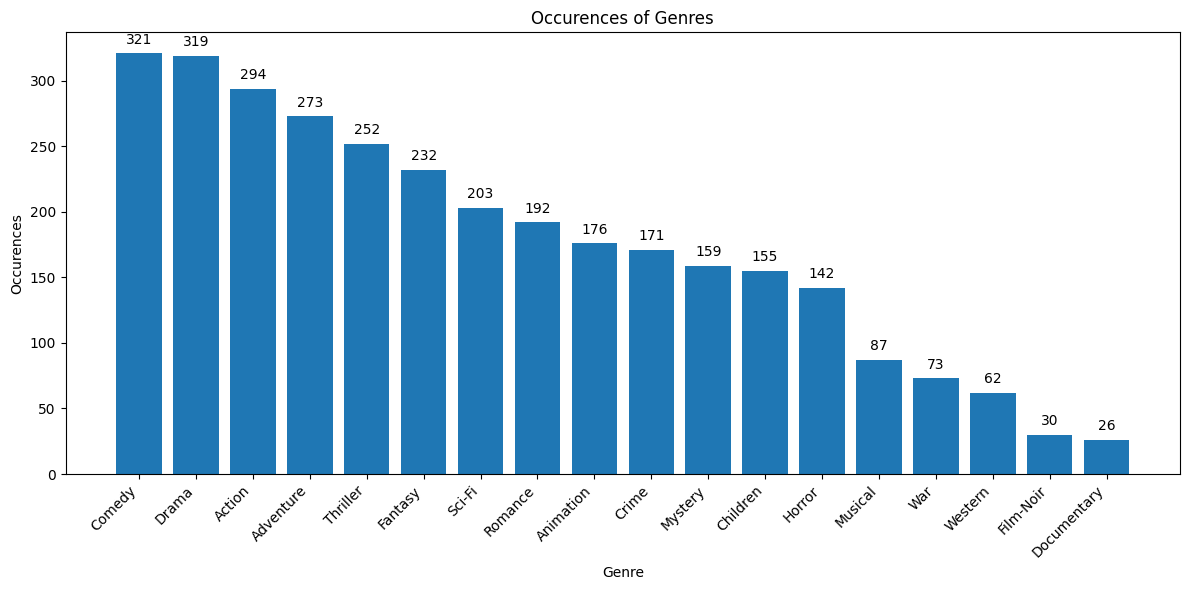

In [136]:
df_genres = pd.DataFrame(list(hi.items()), columns=['genre', 'Occurences'])
df_genres = df_genres.sort_values(by='Occurences', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(df_genres['genre'], df_genres['Occurences'])
plt.xlabel('Genre')
plt.ylabel('Occurences')
plt.title('Occurences of Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

In [137]:
df[df.genres == 'Adventure']

,movieId,original_title,genres,actors,directors,overview,original_language,poster_path,avg_rating,total_rating_users,popularity_score,tmdbId,decade
720,941,The Mark of Zorro,Adventure,Tyrone Power|Linda Darnell|Basil Rathbone|Gale...,Rouben Mamoulian,"In 1820 Spain, the son of a California noblema...",en,https://image.tmdb.org/t/p/w500/bJDonmAPnDV8jD...,3.75,2,4.119796,32093,40s
1862,2477,Firewalker,Adventure,Chuck Norris|Louis Gossett Jr.|Melody Anderson...,J. Lee Thompson,A pair of adventurers try to track down an anc...,en,https://image.tmdb.org/t/p/w500/qFUBCOH0HxI9qR...,3.33,3,4.620981,12715,80s
1909,2537,Beyond the Poseidon Adventure,Adventure,Michael Caine|Sally Field|Telly Savalas|Peter ...,Irwin Allen,"After ""The Poseidon Adventure"", in which the s...",en,https://image.tmdb.org/t/p/w500/hTsUNXz38lIvDl...,2.00,3,2.772589,31638,70s
3622,4988,White Water Summer,Adventure,Kevin Bacon|Sean Astin|Jonathan Ward|K.C. Mart...,Jeff Bleckner,When the experienced guide Vic accompanies the...,en,https://image.tmdb.org/t/p/w500/jvoxMkXms4O490...,2.00,1,1.386294,19209,80s
3808,5357,Iron Will,Adventure,Mackenzie Astin|Kevin Spacey|Brian Cox|David O...,Charles Haid,"When Will Stoneman's father dies, he is left a...",en,https://image.tmdb.org/t/p/w500/vYsSu7DdgU4yqb...,3.50,2,3.845143,24767,90s
3809,5358,Mountains of the Moon,Adventure,Patrick Bergin|Iain Glen|Richard E. Grant|Fion...,Bob Rafelson,The story of Captain Richard Francis Burton's ...,en,https://image.tmdb.org/t/p/w500/uWWrigxf4yU1Wm...,3.00,1,2.079442,33796,90s
3810,5361,White Fang,Adventure,Klaus Maria Brandauer|Ethan Hawke|Seymour Cass...,Randal Kleiser,Jack London's classic adventure story about th...,en,https://image.tmdb.org/t/p/w500/27wg0rVZW8hX7n...,1.75,2,1.922572,12227,90s
4810,7205,The Wind and the Lion,Adventure,Sean Connery|Candice Bergen|Brian Keith|John H...,John Milius,At the beginning of the 20th century an Americ...,en,https://image.tmdb.org/t/p/w500/3QLqEZL1kBBfKj...,3.00,1,2.079442,14815,70s
7043,70703,Christopher Columbus: The Discovery,Adventure,Georges Corraface|Marlon Brando|Tom Selleck|Ra...,John Glen,Genoan navigator Christopher Columbus has a dr...,en,https://image.tmdb.org/t/p/w500/2VUr81cOU0jsZt...,2.00,1,1.386294,41682,90s
8846,136912,God Loves Caviar,Adventure,Sebastian Koch|Evgeniy Stychkin|Juan Diego Bot...,Yannis Smaragdis,"The true-life, stranger-than-fiction tale of e...",el,https://image.tmdb.org/t/p/w500/owFV0qujjF1l3T...,2.00,1,1.386294,128767,2010s


In [138]:
ai = {}
data = df[df.genres.str.contains('(no genres listed)')]

data.genres.value_counts()

/tmp/ipython-input-3357349294.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data = df[df.genres.str.contains('(no genres listed)')]


,count
genres,


In [139]:
hi

{'Western': 62,
 'Action': 294,
 'Thriller': 252,
 'Musical': 87,
 'Film-Noir': 30,
 'Sci-Fi': 203,
 'Horror': 142,
 'Drama': 319,
 'Mystery': 159,
 'Documentary': 26,
 'Comedy': 321,
 'Crime': 171,
 'Animation': 176,
 'Adventure': 273,
 'Romance': 192,
 'Fantasy': 232,
 'War': 73,
 'Children': 155}

In [140]:


df['genres'] = df['genres'].str.replace(r'\|?IMAX\|?', '', regex=True).str.strip('|')  # Remove IMAX and extra pipes
df['genres'] = df['genres'].replace('', '(no genres listed)')  # Handle any now-empty genres

# Verify: Recount combinations
genre_counts = df['genres'].value_counts()
print(genre_counts[genre_counts > 50])  # Check top combos post-removal

# Optional: Create a separate flag
# df['is_IMAX'] = df['genres_original'].str.contains('IMAX', na=False)  # If you saved original genres

genres
Drama                          1046
Comedy                          942
Comedy|Drama                    434
Comedy|Romance                  363
Drama|Romance                   345
Documentary                     304
Comedy|Drama|Romance            275
Horror                          169
Drama|Thriller                  165
Horror|Thriller                 136
Crime|Drama                     134
Crime|Drama|Thriller            125
Drama|War                       110
Comedy|Crime                    100
Action|Comedy                    93
Thriller                         84
Action|Adventure|Sci-Fi          82
Children|Comedy                  74
Comedy|Horror                    70
Action|Crime|Thriller            69
Action|Drama                     63
Action|Crime|Drama|Thriller      62
Action                           60
Action|Thriller                  60
Horror|Sci-Fi                    52
Action|Crime|Drama               52
Name: count, dtype: int64


In [112]:
df['avg_rating'] = round(df['avg_rating'], 2)
df['total_rating_users'] = df['total_rating_users'].astype(int)
df['tmdbId'] = df['tmdbId'].astype(int)

In [141]:
# Drop rows where the 'genres' column is '(no genres listed)'
df = df[df.genres != '(no genres listed)']

# Display the head of the DataFrame to verify the removal
print("DataFrame after dropping '(no genres listed)' genre:")
display(df.head())

DataFrame after dropping '(no genres listed)' genre:


,movieId,original_title,genres,actors,directors,overview,original_language,poster_path,avg_rating,total_rating_users,popularity_score,tmdbId,decade
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,John Lasseter,"Led by Woody, Andy's toys live happily in his ...",en,https://image.tmdb.org/t/p/w500/uXDfjJbdP4ijW5...,3.92,215,21.076092,862,90s
1,2,Jumanji,Adventure|Children|Fantasy,Robin Williams|Kirsten Dunst|Bradley Pierce|Bo...,Joe Johnston,When siblings Judy and Peter discover an encha...,en,https://image.tmdb.org/t/p/w500/vgpXmVaVyUL7GG...,3.43,110,16.162251,8844,90s
2,3,Grumpier Old Men,Comedy|Romance,Walter Matthau|Jack Lemmon|Ann-Margret|Sophia ...,Howard Deutch,A family wedding reignites the ancient feud be...,en,https://image.tmdb.org/t/p/w500/1FSXpj5e8l4KH6...,3.26,52,12.941625,15602,90s
3,4,Waiting to Exhale,Comedy|Drama|Romance,Whitney Houston|Angela Bassett|Loretta Devine|...,Forest Whitaker,"Cheated on, mistreated and stepped on, the wom...",en,https://image.tmdb.org/t/p/w500/qJU6rfil5xLVb5...,2.36,7,4.901541,31357,90s
4,5,Father of the Bride Part II,Comedy,Steve Martin|Diane Keaton|Martin Short|Kimberl...,Charles Shyer,Just when George Banks has recovered from his ...,en,https://image.tmdb.org/t/p/w500/rj4LBtwQ0uGrpB...,3.07,49,12.015499,11862,90s


In [142]:
data = df.head(4).to_dict()

In [143]:
data

{'movieId': {0: 1, 1: 2, 2: 3, 3: 4},
 'original_title': {0: 'Toy Story',
  1: 'Jumanji',
  2: 'Grumpier Old Men',
  3: 'Waiting to Exhale'},
 'genres': {0: 'Adventure|Animation|Children|Comedy|Fantasy',
  1: 'Adventure|Children|Fantasy',
  2: 'Comedy|Romance',
  3: 'Comedy|Drama|Romance'},
 'actors': {0: 'Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wallace Shawn',
  1: 'Robin Williams|Kirsten Dunst|Bradley Pierce|Bonnie Hunt|Jonathan Hyde',
  2: 'Walter Matthau|Jack Lemmon|Ann-Margret|Sophia Loren|Daryl Hannah',
  3: 'Whitney Houston|Angela Bassett|Loretta Devine|Lela Rochon|Gregory Hines'},
 'directors': {0: 'John Lasseter',
  1: 'Joe Johnston',
  2: 'Howard Deutch',
  3: 'Forest Whitaker'},
 'overview': {0: "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put a

In [144]:
df.isnull().sum()

,0
movieId,0
original_title,0
genres,0
actors,0
directors,0
overview,0
original_language,0
poster_path,0
avg_rating,0
total_rating_users,0


In [145]:
genres_df = df['genres'].str.get_dummies('|')  # Creates binary columns for each genre
to_df = pd.concat([df, genres_df], axis=1)

# Step 2: Crosstab of genres vs. decade
# Use the genre column names directly from the concatenated DataFrame 'to_df'
genre_decade_crosstab = pd.crosstab(to_df['decade'], [to_df[col] for col in genres_df.columns])
print("Genre vs. Decade Crosstab:")
print(genre_decade_crosstab)

Genre vs. Decade Crosstab:
Action       0                                ...  1                          \
Adventure    0                                ...  1                           
Animation    0                                ...  1                           
Children     0                                ...  0  1                        
Comedy       0                                ...  1  0           1            
Crime        0                                ...  1  0           0            
Documentary  0                                ...  0  0           0            
Drama        0                                ...  0  0           0            
Fantasy      0                                ...  0  0     1     0            
Film-Noir    0                                ...  0  0     0     0            
Horror       0                                ...  0  0     0     0            
Musical      0                                ...  0  0     0     0            
Mystery      


Mean Avg_Rating per Genre:
             avg_rating
Action         3.089945
Adventure      3.208328
Animation      3.476388
Children       3.109788
Comedy         3.176370
Crime          3.288162
Documentary    3.732545
Drama          3.409250
Fantasy        3.209431
Film-Noir      3.585977
Horror         2.910238
Musical        3.272691
Mystery        3.322986
Romance        3.353237
Sci-Fi         3.084591
Thriller       3.144448
War            3.561046
Western        3.381386


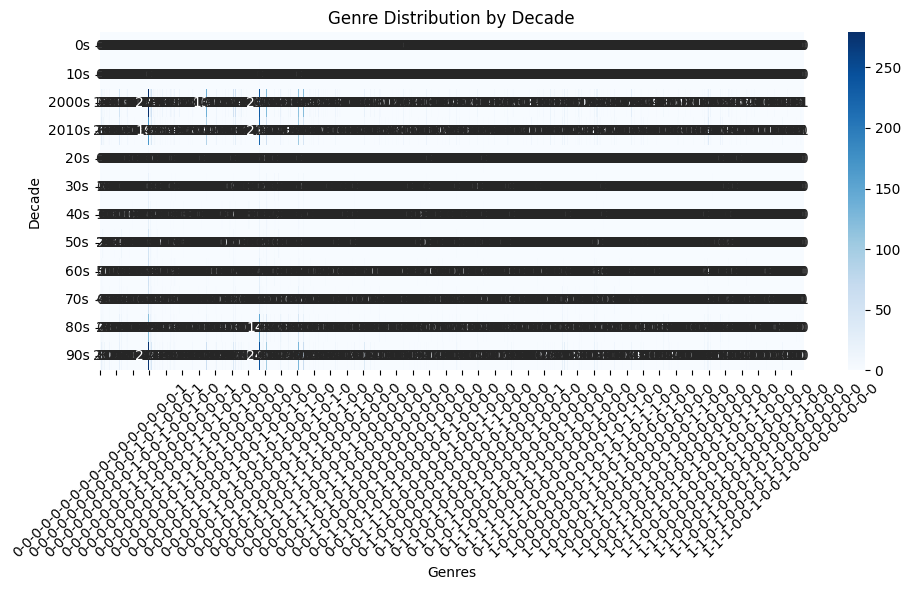

In [146]:
# Step 3: Calculate mean avg_rating per genre
genre_ratings = {}
for genre in genres_df.columns:
    genre_ratings[genre] = to_df[to_df[genre] == 1]['avg_rating'].mean()
genre_ratings_df = pd.DataFrame.from_dict(genre_ratings, orient='index', columns=['avg_rating'])
print("\nMean Avg_Rating per Genre:")
print(genre_ratings_df)

# Step 4: Visualizations
# Heatmap for genres vs. decade
plt.figure(figsize=(10, 6))
sns.heatmap(genre_decade_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Genre Distribution by Decade')
plt.xlabel('Genres')
plt.ylabel('Decade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<Figure size 1000x600 with 0 Axes>

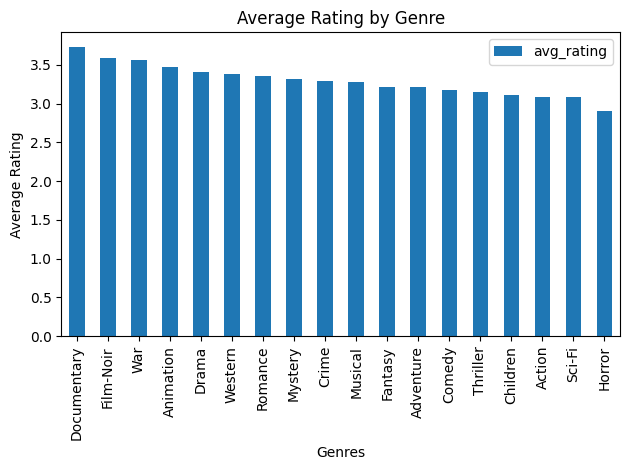

In [147]:
# Bar chart for avg_rating per genre
plt.figure(figsize=(10, 6))
genre_ratings_df.sort_values('avg_rating', ascending=False).plot(kind='bar')
plt.title('Average Rating by Genre')
plt.xlabel('Genres')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()